**변경사항**

통계 해석 추가

데이터 로드 파일 변경

3-6. 머신러닝을 위한 데이터 저장 주석 처리

통계 검정(Welch's T-test ,Mann-Whitney U) 함수로 변경

## Product-type 2 - 통계
- 데이터 로드
- 기술 통계량 확인
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (환경 변수)
    - 전체 샘플 수 대비 불량률
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (환경 변수)
- 전체 샘플 수 대비 불량 제품의 비율
- Box-Plot
    - 공정/환경변수 
- Welch's T-test
    - 공정/환경변수
- Mann-Whitney U 검정
    - 공정/환경변수    

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [2]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_2 = pd.read_csv('for_통계_process_data_product-2.csv')
df_sensor_2 = pd.read_csv('for_통계_sensor_data_product-2.csv')
df_defects_2 = pd.read_csv('for_통계_defects_data_product-2.csv')
df_original_2 = pd.read_csv('for_통계_overall_data_product-2.csv')

In [3]:
# 2. 데이터 크기 확인
print(f"제품 2의 전체 데이터 크기: {df_original_2.shape}")
print(f"제품 2의 전체 데이터 컬럼: {df_original_2.columns}")

print(f"제품 2의 process 관련 데이터 크기: {df_process_2.shape}")
print(f"제품 2의 process 관련 데이터 컬럼: {df_process_2.columns}")

print(f"제품 2의 sensor 관련 데이터 크기: {df_sensor_2.shape}")
print(f"제품 2의 sensor 관련 데이터 컬럼: {df_sensor_2.columns}")

print(f"제품 2의 defects 관련 데이터 크기: {df_defects_2.shape}")
print(f"제품 2의 defects 관련 데이터 컬럼: {df_defects_2.columns}")


제품 2의 전체 데이터 크기: (3328, 24)
제품 2의 전체 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
       'melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity',
       'surface_defect', 'structural_defect', 'contamination_defect'],
      dtype='object')
제품 2의 process 관련 데이터 크기: (3328, 15)
제품 2의 process 관련 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='object')
제품 2의 sensor 관련 데이터 크기: (3328, 6)
제품 2의 sensor 관련 데이터 컬럼: Index(['melting_furnace_temp', 'ai

In [4]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 3-1. 행을 기준으로 1이 존재하면 불량으로 표현
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 3-2. 불량 데이터프레임
df_defects_2['is_defect'] = df_defects_2[defect_cols].max(axis=1)
# 3-3. is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_2_1 = df_defects_2.drop(columns=defect_cols)


display(df_defects_2_1.head(5))

,is_defect
0,0
1,0
2,0
3,0
4,0


In [5]:
# 3-4. 전체 데이터프레임
df_original_2['is_defect'] = df_original_2[defect_cols].max(axis=1)
# 3-5. is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_2_1 = df_original_2.drop(columns=defect_cols)

display(df_original_2_1.head(5))

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


In [6]:
# 3-6. 머신러닝을 위한 데이터 저장
# df_original_2_1.to_csv("../data/ML_modeling_data_product-2.csv", index=False)

---
---
### 2. 기술통계

In [7]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [10]:
create_statistics_summary(df_process_2, "process")
create_statistics_summary(df_sensor_2, "sensor")



process의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,-0.723734
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,-0.215835
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,-15.937863
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,-0.645471
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,-1.538814
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,28.736696
pressure_rise_time,3328.0,0.036638,0.002946,0.031,0.0340,0.036,0.040,0.045,0.692732



sensor의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,1.401438
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,-1.083763


In [50]:
# 2. 전체 샘플 수 & 불량률
total    = len(df_original_2_1)
n_defect = df_original_2_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"=== 전체 데이터 대비 불량률 ===")
print(f"\n전체 샘플 : {total:,}개")
print(f"불량      : {int(n_defect):,}개")
print(f"정상      : {int(n_normal):,}개")
print(f"불량률    : {rate:.2f}%")

=== 전체 데이터 대비 불량률 ===

전체 샘플 : 3,328개
불량      : 946개
정상      : 2,382개
불량률    : 28.43%


#### **2.2 해석**
product type 2의 데이터는 총 3,2328개의 관측치로 구성되어 있으며,\
이중 양품이 2,3282개, 불량이 946개로. 불량률이 28.43%이다.

1. process 데이터 기술통계 해석\
공정변수는 대체로 안정적인 형태이나, cycle_time, cylinder_pressure와 같은 변수가 극단값의 영향이 강하게 나타난다.

2. sensor 데이터 기술통계 해석\
온도/압력/습도 안정적인 형태를 띄고 있다.

---
---
### 3. 정규성 검정

#### 3.1 Shapiro-Wilk 검정

In [51]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"제품 2의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 정규성 확인: Shapiro-Wilk
        stat, p_value = stats.shapiro(series)

        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])

    # 출력
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [52]:
# 2. 함수 실행
shapiro_df_original_2 = create_shapiro_summary(
    df_original_2_1,
    "공정/센서",
    exclude_cols=['shot_key', 'is_defect',]
)


제품 2의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.926543,1.316477e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.984859,2.096279e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,0.253951,7.152509e-79,정규성 불만족
rapid_rise_time,0.760192,1.013079e-56,정규성 불만족
biscuit_thickness,0.889750,1.039510e-43,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족
cycle_time,0.153969,1.478039e-81,정규성 불만족


#### 3.2 Q-Q Plot

In [53]:
# 1. Q-Q plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    """QQplot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

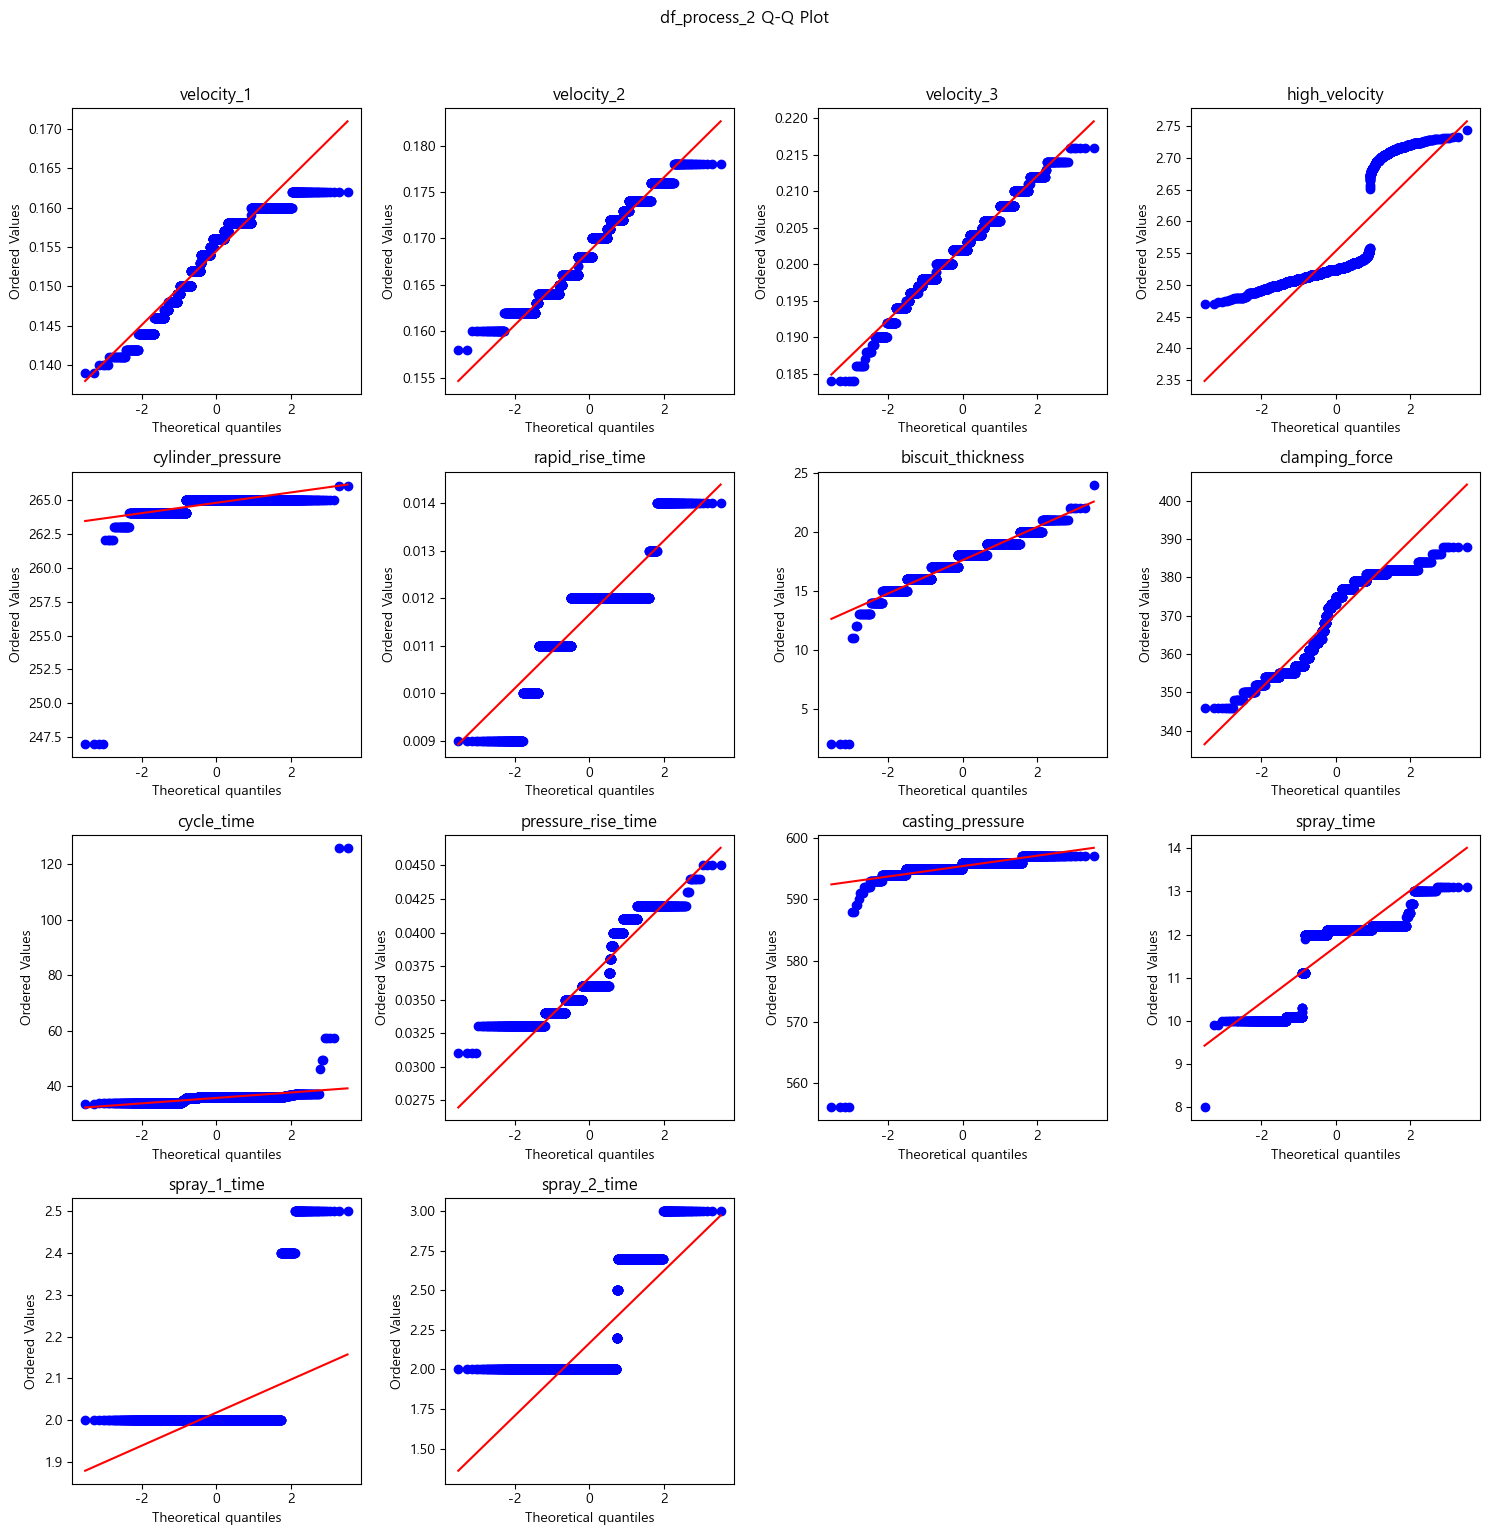

In [54]:
# 2. 함수 실행
plot_qq_table(df_process_2, 
            title="df_process_2 Q-Q Plot")

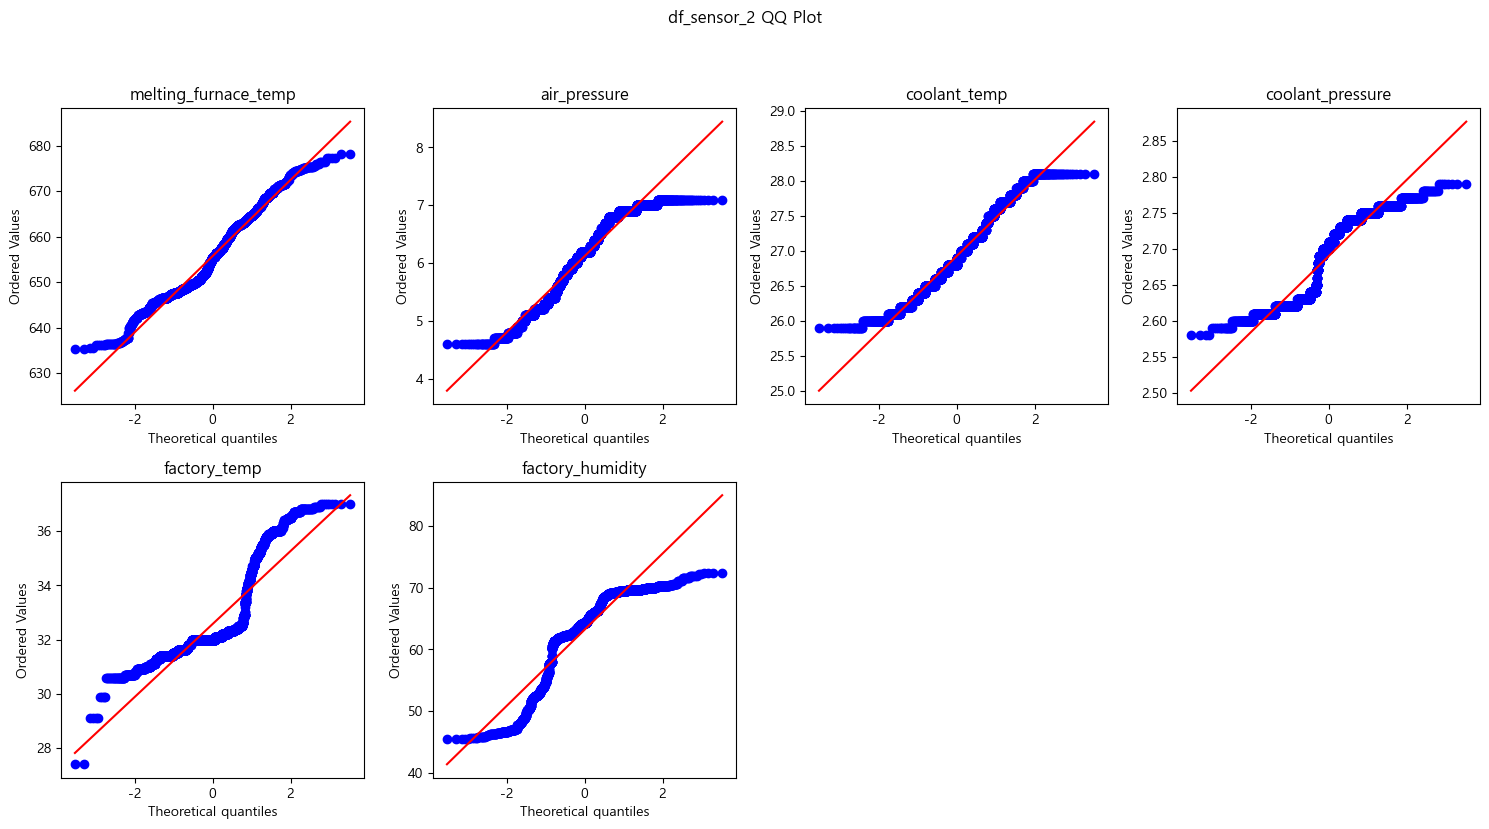

In [55]:
plot_qq_table(df_sensor_2, 
            title="df_sensor_2 QQ Plot")

#### **정규성 분석 결과**
1. Shapiro-Wilk\
process, sensor 모든 변수에서 p-value가 거의 0으로 정규성을 만족하지 못한다.\
다만, 표본 수가 3328개로 큰 편으로, Shapiro–Wilk 검정은 분포가 조금만 비대칭이거나 이산적이어도 정규성이 쉽게 기각될 수 있다.\
→ 그래서 p-value만 보고 "완전 비정규다"라 단정하기보단 QQ plot도 함께 확인하여 분포 형태를 종합적으로 해석하는 것이 적절하다.

2. QQ plot 해석
    1. process QQ plot: 값 대부분을 정규성 분포로 보기 어렵다.
        - 여러 변수에서 점들이 계단 형태로 나타나 연속형 정규분포로 보기 어려운 패턴이 관찰된다. (velocity, rapid_rise_time 등)
        - cycle_time은 상단 꼬리가 크게 튐(극단값)
        - spray_1_time 같이 거의 일정한 변수는 분포 자체가 한 줄에 가까움
    2. sensor QQ plot: 값 대부분을 정규성 분포로 보기 어렵다.
        - 직선에서 벗어나는 구간이 존재하며, 일부 변수는 꼬리 부분에서 이탈이 나타난다.
        - 환경/설비 센서 변수는 특성상 왜도나 꼬리가 생길 수 있으나\
        전반적으로 정규분포로 보기에는 부적합한 형태가 확인된다.

#### 3.3 Levene 검증

In [56]:
from scipy.stats import levene

# 1. 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

        
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [57]:
# 2. 함수 실행
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key']
)


df_process_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,4.480292,3.436193e-02,등분산 가정 불가
velocity_2,0.730217,3.928743e-01,등분산 가정 가능
velocity_3,1.830792,1.761259e-01,등분산 가정 가능
high_velocity,188.751329,8.084364e-42,등분산 가정 불가
cylinder_pressure,5.546086,1.857985e-02,등분산 가정 불가
rapid_rise_time,0.714535,3.980031e-01,등분산 가정 가능
biscuit_thickness,0.580366,4.462228e-01,등분산 가정 가능
clamping_force,163.045258,1.734345e-36,등분산 가정 불가
cycle_time,15.444339,8.669984e-05,등분산 가정 불가


In [58]:
process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2_1,
    "is_defect",
    "df_sensor_2",
)


df_sensor_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,19.173745,1.230211e-05,등분산 가정 불가
air_pressure,24.267707,8.792250e-07,등분산 가정 불가
coolant_temp,3.906079,4.819422e-02,등분산 가정 불가
coolant_pressure,7.258745,7.091103e-03,등분산 가정 불가
factory_temp,108.956851,4.036253e-25,등분산 가정 불가
factory_humidity,176.767310,2.442028e-39,등분산 가정 불가


#### **등분산성(Levene) 결과 해석**
1. process (is_defect 기준)
    - high_velocity, clamping_force, cycle_time, spray_time, spray_2_time 등\
    등분산 가정 불가하다.
    - velocity_2, velocity_3, rapid_rise_time, biscuit_thickness, pressure_rise_time, casting_pressure 등\
    등분산 가정 가능 하다.
    - process는 변수별로 섞여 있지만, 등분산 깨지는 변수가 적지 않다.
2. sensor (is_defect 기준)
    - sensor는 등분산성 가정이 전반적으로 깨진다고 보고 가는 게 자연스럽다.

#### 3.4 스피어만 상관계수 히트맵

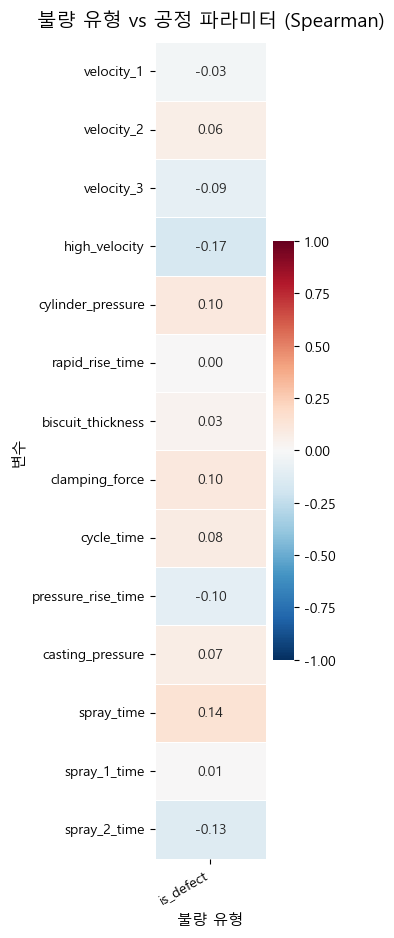

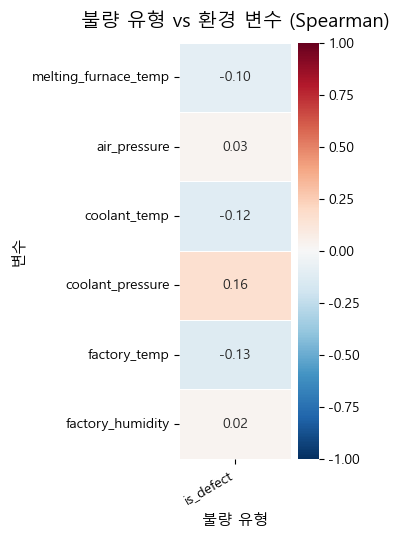

In [59]:
# 1. 변수 정의
DEFECT_COLS = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 2. 스피어만 상관계수 히트맵 시각화 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 함수 출력
plot_corr_heatmap(df_original_2_1, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2_1, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

#### **스피어만 상관계수 해석**
공정/센서 변수 모두에서 상관계수 절댓값이 대체로 0.00 ~ 0.17 수준으로 크지 않게 나타났으며,\
단일 변수 1개가 불량 여부를 강하게(단조롭게) 설명하는 관계는 약한 편이다.

즉, 불량은 단일 변수보다는 복합적인 조건(조합/임계값/비선형 관계)의 영향을 받을 가능성이 있어\
상관만으로 "불량의 원인"을 단정하기보다,\
이후 집단 차이 검정(Welch/MWU)이나 모델 기반 중요도에서 함께 판단하는것이 적절하다.

#### 3.5 결측치 개수 확인
- 통계적 검정방법을 수행하기 전, 결측치 개수 확인

In [60]:
# 1. 결측치 확인
print("\n=== 전체 데이터 기준 결측치 개수 ===")
print(f"{df_original_2_1.isnull().sum().sum()}개")


=== 전체 데이터 기준 결측치 개수 ===
0개


#### 3.6 Box Plot

In [61]:
# 1. box plot 시각화 함수 정의
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 비어있는 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

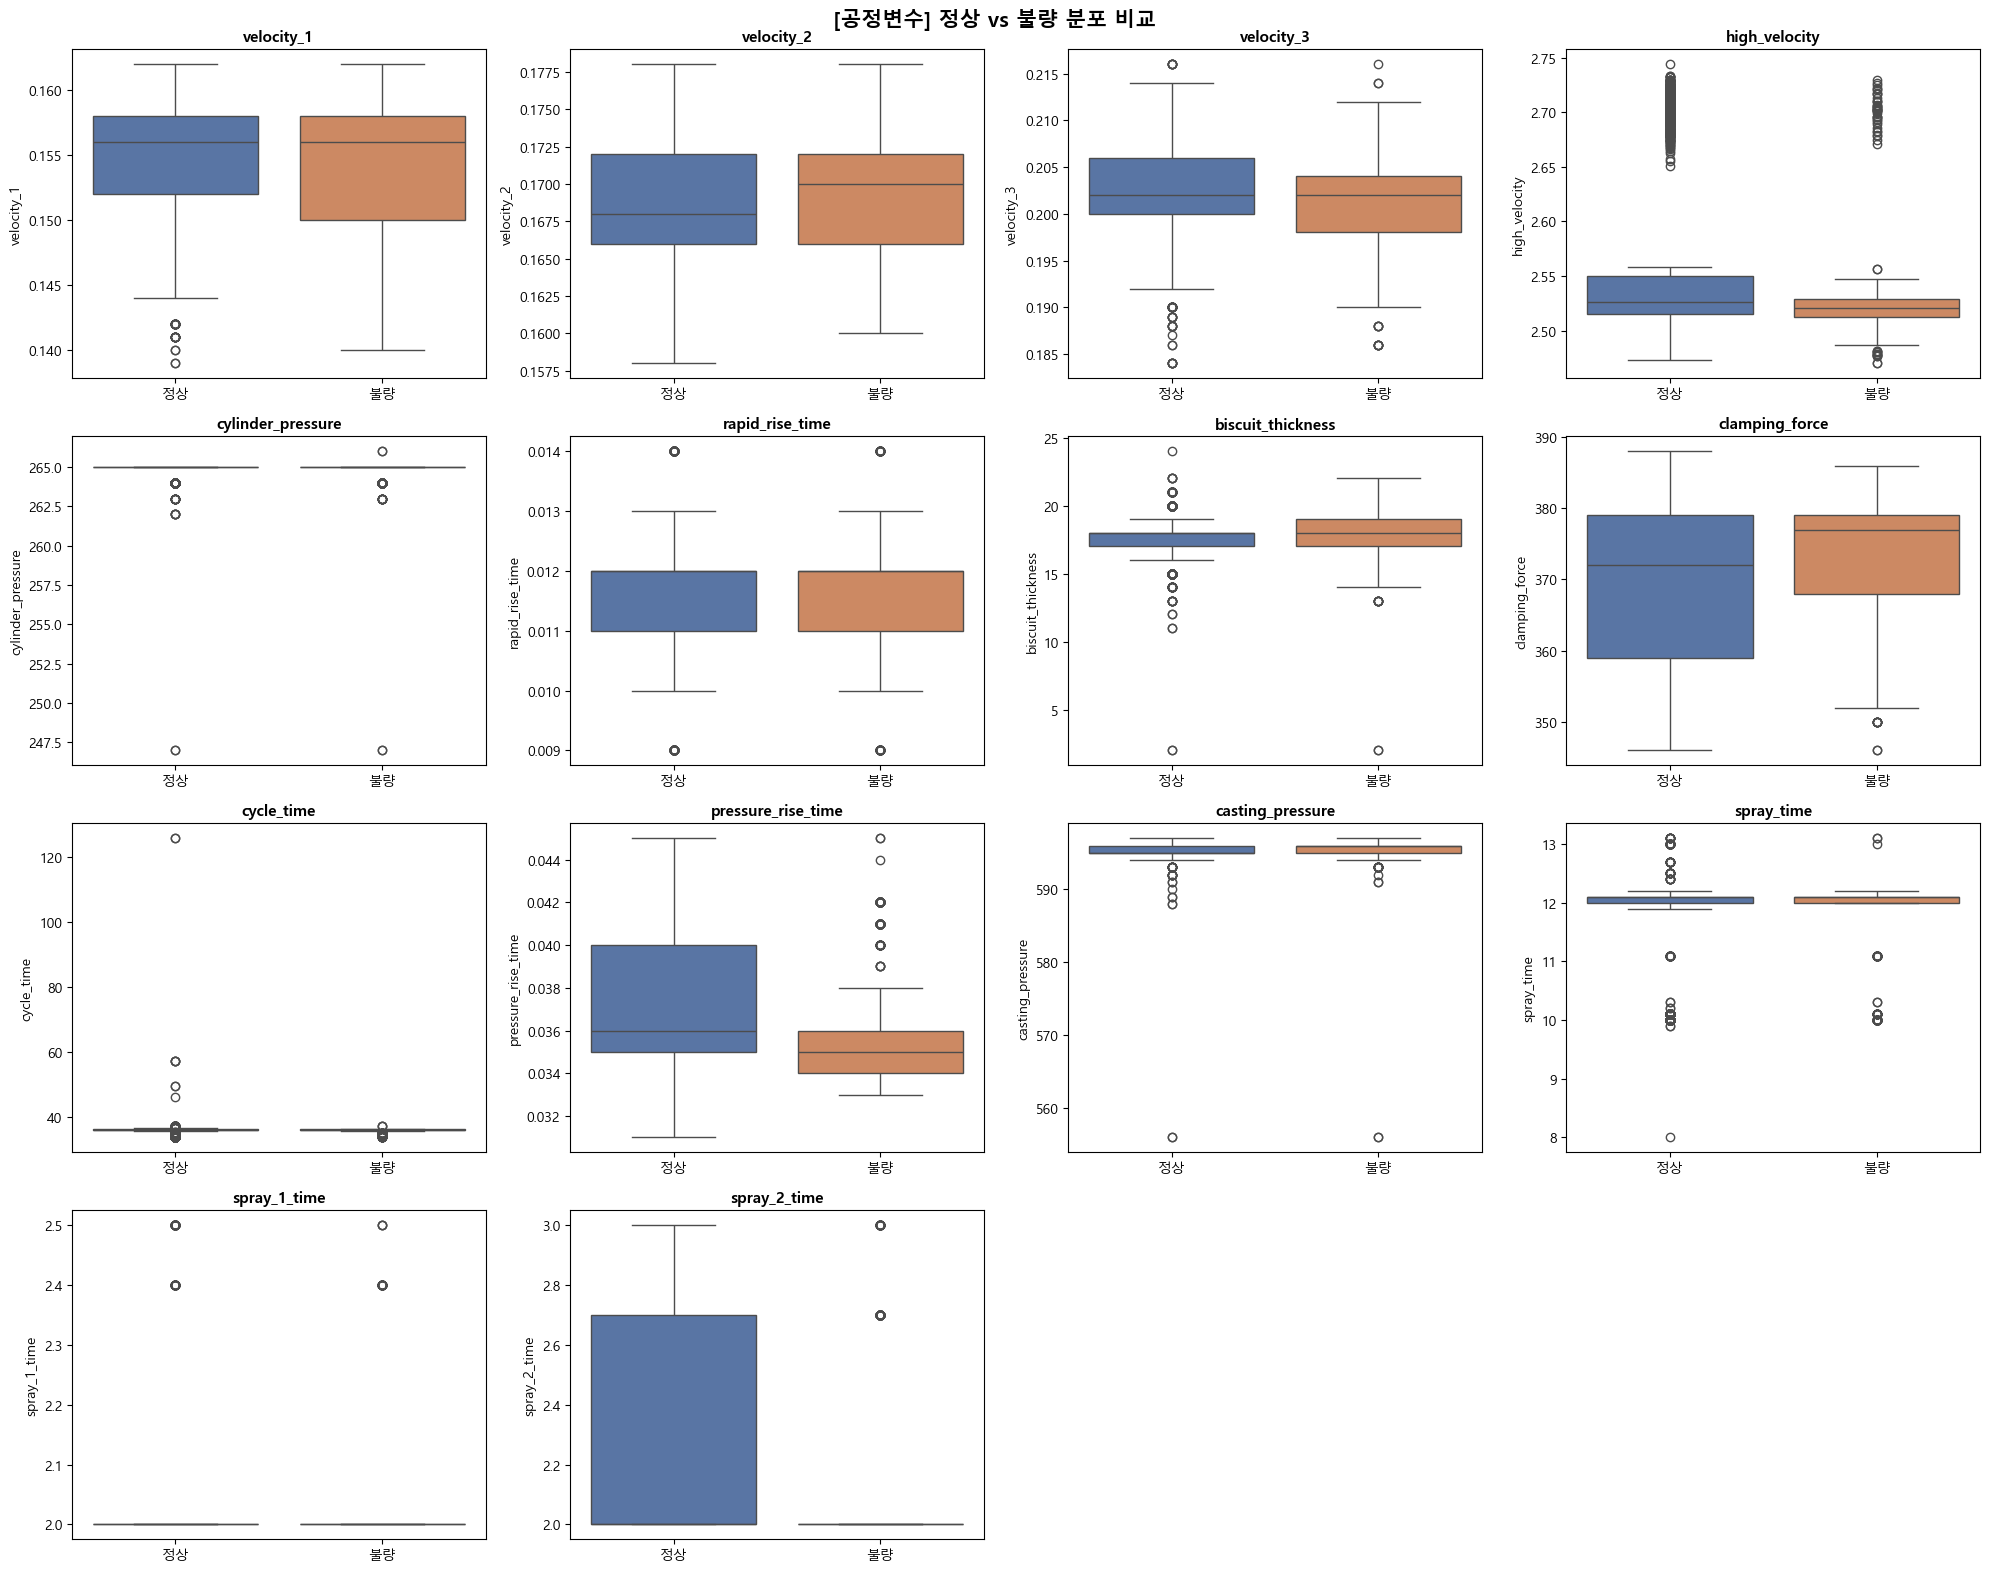

In [62]:
# 2. 함수 실행
boxplot_of_process_1 = plot_boxplots(df_original_2_1, PROCESS_COLS, "공정변수")

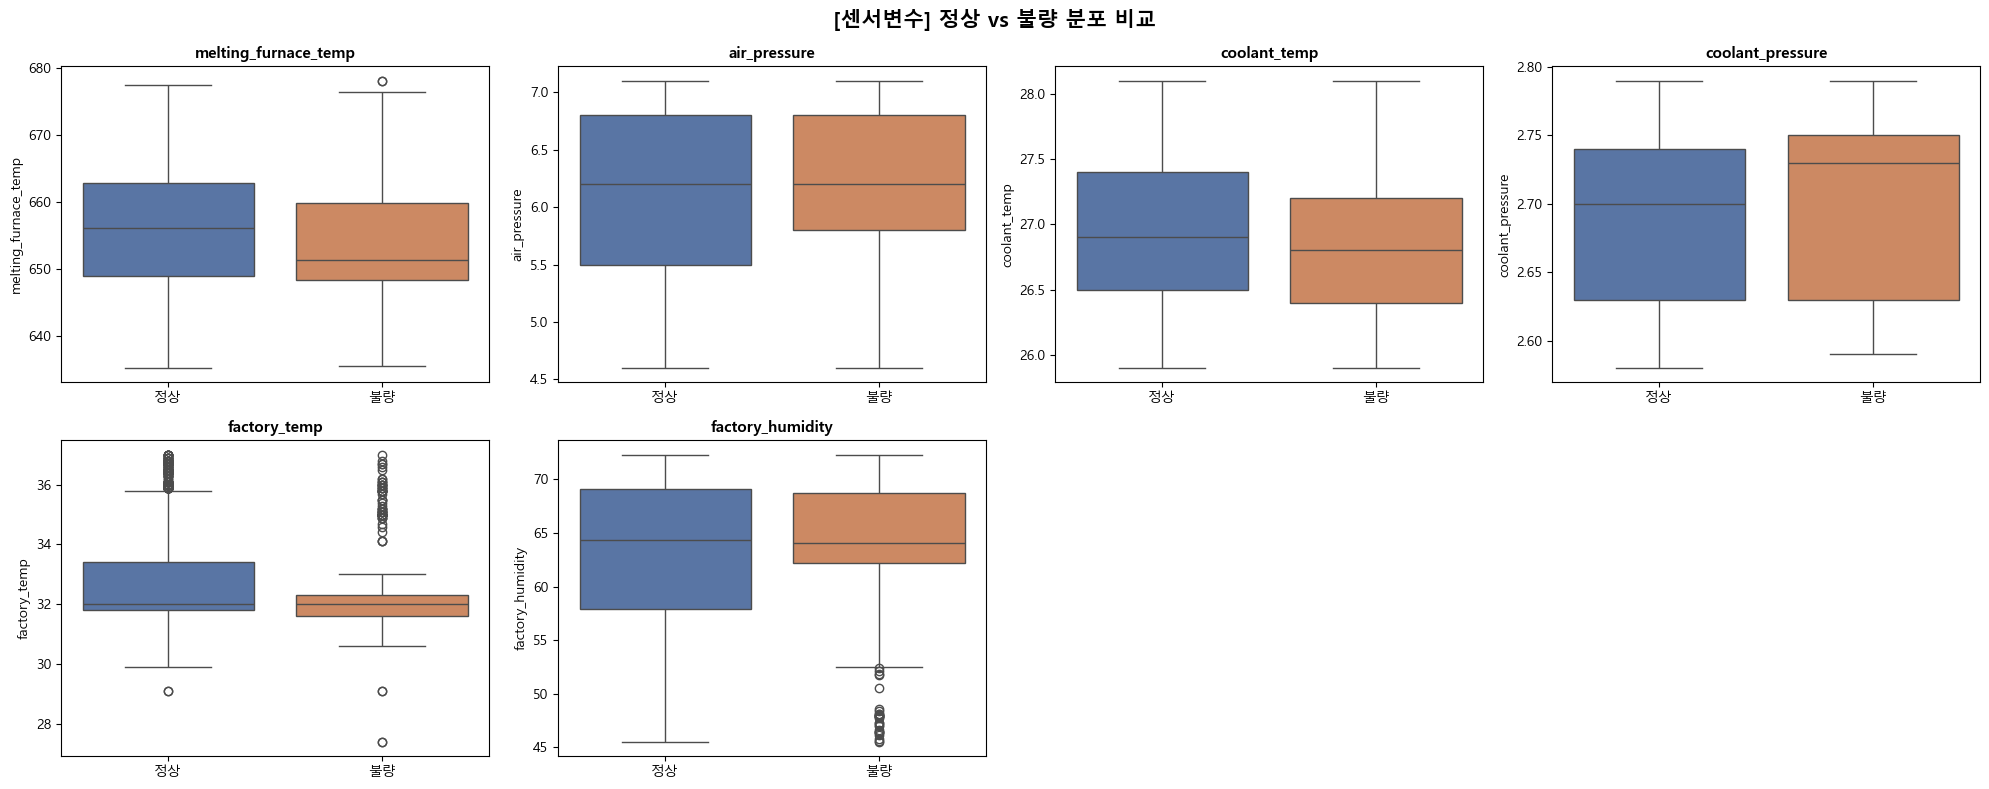

In [63]:
boxplot_of_sensor_1 = plot_boxplots(df_original_2_1, SENSOR_COLS, "센서변수")

#### **박스플롯 해석**
1. df_process(공정 변수) 관점
    - high_velocity: 불량 쪽이 정상보다 조금 낮은 방향으로 이동해 보이고, 상단 이상치/꼬리도 양상이 다르다.
    - 공정 변수는 박스플롯 기준으로 high_velocity가 가장 직관적으로 차이가 보이며\
    나머지는 "약한 이동 + 겹침 많음" 형태가 많이 보인다.

2. df_sensor(센서 변수) 관점
    - coolant_pressure: 불량 그룹이 정상보다 약간 높은 방향으로 이동한다.
    - factory_temp: 불량 그룹 중앙값이 정상보다 높은 쪽으로 이동하는 경향이 보인다.
    - 센서 변수 중 coolant_pressure와 factory_temp가 정상/불량 분포 차이가 상대적으로 더 관찰된다.

---
---
### 4. 통계적 검정

#### 4.1 Welch's T-test

In [64]:
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(group1) - np.mean(group2)) / s_pooled

In [65]:
from scipy.stats import ttest_ind

# Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값 조정
        result_list.append([
            col,
            t_stat,
            cohen_d,
            effect,
            p_value,
            result
            
        ])


    # 출력화면 조정
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "요인",
            "t-통계량", 
            "Cohen's d", 
            "효과크기 판정",
            "p-value", 
            "통계적 유의성 여부"
        ]
    ).set_index("요인")
    
    # 절댓값 기준 효과크기 절대값 내림차순으로 나열
    welch_df = welch_df.sort_values("Cohen's d", key=abs, ascending=False)
    display(welch_df)
    
    return welch_df

In [66]:
welch_surface = create_welch_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,t-통계량,Cohen's d,효과크기 판정,p-value,통계적 유의성 여부
요인,,,,,
high_velocity,17.553665,0.515336,큰 효과,6.444589e-66,True
factory_temp,13.715566,0.441795,중간 효과,2.104785e-41,True
coolant_pressure,-8.175501,0.317986,중간 효과,5.711403e-16,True
clamping_force,-8.933557,0.317252,중간 효과,8.894569e-19,True
coolant_temp,6.806628,0.260440,작은 효과,1.367599e-11,True
factory_humidity,-8.148410,0.259178,작은 효과,5.567848e-16,True
spray_2_time,7.137874,0.259159,작은 효과,1.327725e-12,True
spray_time,-7.622387,0.257419,작은 효과,3.593887e-14,True
velocity_3,5.483617,0.207639,작은 효과,4.760016e-08,True


##### **Welch t-test 결과 해석**

1. df_process (α=0.05)
    1. 유의하게 나온 변수
        - velocity_2, velocity_3, high_velocity, cylinder_pressure, clamping_force, pressure_rise_time, spray_time, spray_2_time
    2.  유의하지 않게 나온 변수
        - velocity_1, rapid_rise_time, biscuit_thickness, cycle_time, casting_pressure, spray_1_time
    3. 효과크기 관점
        - high_velocity, clamping_force\
        나머지는 대체로 작은 효과\
        특히 high_velocity는 p-value가 극단적으로 작고 효과 크기도 크다.

2. df_sensor
    1. 유의성
        - 센서 변수는 전부 유의로 나왔다.
    2. 효과크기 관점
        - 중간 효과: factory_temp, coolant_pressure\
        → 이 둘이 "불량 vs 비불량" 차이가 비교적 뚜렷한 편
        - 나머지는 작은~매우 작은 효과

3. 해석\
df_process: high_velocity, clamping_force (특히 high_velocity) \
df_sensor: factory_temp, coolant_pressure\
이 변수들은 불량 그룹과 비불량 그룹을 구분하는 후보 변수로 보인다.

#### 4.2 Mann-Whitney U 검정

In [67]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()

        # Mann–Whitney U
        # 입력 순서가 중요 group_1을 먼저 넣으면, RBC 부호 해석이 직관적이 됨
        #  RBC > 0  → 불량(1) 그룹 값이 더 큰 경향
        #  RBC < 0  → 불량(1) 그룹 값이 더 작은 경향

        # Pingouin(pg.mwu)은 U 통계량, p-value, 효과크기(RBC)를 한 번에 반환함
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        u_stat  = out["U_val"].values[0] # u_stat
        p_value = out["p_val"].values[0] # p_value
        # 효과크기: rank-biserial correlation
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값
        result_list.append([
            col, 
            u_stat, 
            rbc,
            effect,
            p_value, 
            result
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
                "요인", 
                "U-통계량", 
                "rank-biserial", 
                "효과크기 해석",
                "p-value",
                "통계적 유의성 여부"
            ]
    ).set_index("요인")
    # 절댓값 기준 효과크기 절대값 내림차순으로 나열
    mannwhitney_df = mannwhitney_df.sort_values('rank-biserial', key=abs, ascending=False)
    display(mannwhitney_df)
    
    return mannwhitney_df


In [68]:
mannwhitney_surface = create_mannwhitney_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,U-통계량,rank-biserial,효과크기 해석,p-value,통계적 유의성 여부
요인,,,,,
high_velocity,882524.0,-0.216708,작은 효과,1.543591e-22,True
coolant_pressure,1352485.0,0.200410,작은 효과,1.243316e-19,True
spray_time,1321119.0,0.172571,작은 효과,3.613817e-16,True
factory_temp,946196.0,-0.160195,작은 효과,3.719025e-13,True
coolant_temp,957375.0,-0.150273,작은 효과,1.172337e-11,True
clamping_force,1273253.5,0.130087,작은 효과,4.069019e-09,True
melting_furnace_temp,982148.0,-0.128286,작은 효과,7.423824e-09,True
pressure_rise_time,989396.5,-0.121852,작은 효과,2.404079e-08,True
spray_2_time,990073.0,-0.121252,작은 효과,1.135534e-13,True


#### **Mann-Whitney U 결과 해석**

1. df_process(공정 변수) 관점
    - high_velocity: RBC -0.217 → 불량에서 낮은 쪽으로 치우침 / 효과(작음이지만 공정 중 가장 큼)
    - spray_time: RBC +0.173 → 불량에서 높은 쪽
    - clamping_force: RBC +0.130 → 불량에서 높은 쪽

2. df_sensor(센서 변수) 관점
    - coolant_pressure: RBC +0.200 → 불량에서 높은 쪽
    - factory_temp: RBC -0.160 → 불량에서 낮은 쪽
    - coolant_temp: RBC -0.150 → 불량에서 낮은 쪽

3. 결론 
    1. 공정 후보(우선순위)\
    high_velocity (가장 강함)\
    그 다음: spray_time, clamping_force\
    보조 후보: pressure_rise_time, spray_2_time, velocity_3

    2. 센서 후보(우선순위)\
    coolant_pressure (가장 강함)\
    그 다음: factory_temp\
    보조 후보: coolant_temp, melting_furnace_temp

### 5. **통합분석**
제품유형 2에서 Welch t-test와 Mann–Whitney U 검정을 통합한 결과, 

공정 변수에서는 **high_velocity**가 불량/비불량 집단을 가장 뚜렷하게 구분하는 핵심 후보로 확인되었고, 

센서 변수에서는 **coolant_pressure**가 가장 일관된 신호를 보여 핵심 후보로 선정되었다. 

**spray_time, clamping_force, factory_temp**는 보조 후보로 고려할 수 있다.